# Import Modules

In [1]:
from utils import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

# Validation

In [2]:
issues_df = run_validation()

Issues: 586 row(s)
 - District Issues: 127
 - Partylist Issues: 205
 - Referendum Issues: 254


# Clean Data

In [3]:
dfs_district = []
dfs_partylist = []
dfs_referendum = []

for file_config in OCR_FILES:
    total_pages = file_config["pages"]
    if "district" in file_config["path"]: 
        for page_num in range(1, total_pages, 2):
            df_dict = load_ocr_clean_data(file_config["path"], page_num)
            dfs_district.append(df_dict)
            
    elif "partylist" in file_config["path"]:
        for page_num in range(1, total_pages, 4):
            df_dict = load_ocr_clean_data(file_config["path"], page_num)
            dfs_partylist.append(df_dict)
            
    elif "referendum" in file_config["path"]:
        for page_num in range(1, total_pages, 2):
            df_dict = load_ocr_clean_data(file_config["path"], page_num)
            dfs_referendum.append(df_dict)

In [4]:
district_summary, district_scores = flatten_district(
    dfs_district
)
partylist_summary, partylist_scores = flatten_partylist(
    dfs_partylist
)
referendum_summary, referendum_scores = flatten_referendum(
    dfs_referendum
)

district_scores["คะแนน"] = pd.to_numeric(district_scores["คะแนน"], errors="coerce").fillna(0).astype(int)
partylist_scores["คะแนน"] = pd.to_numeric(partylist_scores["คะแนน"], errors="coerce").fillna(0).astype(int)
referendum_scores["คะแนน"] = pd.to_numeric(referendum_scores["คะแนน"], errors="coerce").fillna(0).astype(int)

In [5]:
district_summary.tail(5)

,unit_key,อำเภอ,ตำบล,หน่วย,จำนวนบัตรทั้งหมด,บัตรดี,บัตรเสีย,ไม่เลือกผู้ใด
274,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,18,480,274,17,3
275,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,19,200,131,4,3
276,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,20,420,256,10,9
277,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,440,287,15,11
278,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,400,212,15,9


In [6]:
district_scores.tail(10)

,unit_key,อำเภอ,ตำบล,หน่วย,ชื่อผู้สมัคร,พรรค,คะแนน
2222,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,นายนาท ฉัพพรรณธนกูร,กล้าธรรม,1
2223,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,นายอิทธิพัทธ์ ภักดีเนติพันธุ์,เศรษฐกิจ,6
2224,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายภาคภูมิ โภคทรัพย์,ประชาธิปัตย์,2
2225,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายพีรภัทร ทองธีรสกุล,เพื่อไทย,13
2226,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายธนายุทธ ยืนยั่ง,ประชาชน,45
2227,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นางสุทธิลักษณ์ ยายิรัมย์,รวมไทยสร้างชาติ,2
2228,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายสนอง เทพอักษรณรงค์,ภูมิใจไทย,145
2229,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายวิเชียร ลานทอง,ประชากรไทย,1
2230,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายนาท ฉัพพรรณธนกูร,กล้าธรรม,3
2231,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายอิทธิพัทธ์ ภักดีเนติพันธุ์,เศรษฐกิจ,1


In [7]:
partylist_summary.tail(5)

,unit_key,อำเภอ,ตำบล,หน่วย,จำนวนบัตรทั้งหมด,บัตรดี,บัตรเสีย,ไม่เลือกผู้ใด
274,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,18,480,269,23,4
275,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,19,200,201,13,0
276,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,20,420,248,7,1
277,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,440,295,11,1
278,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,400,208,18,10


In [8]:
partylist_scores.tail(10)

,unit_key,อำเภอ,ตำบล,หน่วย,พรรค,คะแนน
15893,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไทยสร้างไทย,1
15894,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไทยก้าวใหม่,0
15895,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ประชาอาสาชาติ,0
15896,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,พร้อม,0
15897,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,เครือข่ายชาวนาแห่งประเทศไทย,0
15898,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไทยพิทักษ์ธรรม,0
15899,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ความหวังใหม่,0
15900,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไทยรวมไทย,0
15901,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,เพื่อบ้านเมือง,0
15902,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,พลังไทยรักชาติ,0


In [9]:
referendum_summary.tail(5)

,unit_key,อำเภอ,ตำบล,หน่วย,ผู้มีสิทธิ,ผู้มาใช้สิทธิ,บัตรเสีย
267,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,18,486,0,11
268,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,19,213,138,2
269,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,20,535,256,6
270,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,459,313,11
271,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,198,236,9


In [10]:
referendum_scores.tail(5)

,unit_key,อำเภอ,ตำบล,หน่วย,รายการ,คะแนน
811,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,ไม่เห็นชอบ,86
812,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,ไม่แสดงความคิดเห็น,39
813,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,เห็นชอบ,124
814,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไม่เห็นชอบ,80
815,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไม่แสดงความคิดเห็น,23


In [11]:
district_summary.to_csv("flatten_result/district_summary.csv")
district_scores.to_csv("flatten_result/district_scores.csv")
partylist_summary.to_csv("flatten_result/partylist_summary.csv")
partylist_scores.to_csv("flatten_result/partylist_scores.csv")
referendum_summary.to_csv("flatten_result/referendum_summary.csv")
referendum_scores.to_csv("flatten_result/referendum_scores.csv")

# Insights

## สส.เขต

### 1. คะแนนรวมแต่ละผู้สมัคร

,ชื่อผู้สมัคร,พรรค,คะแนน,% คะแนน
1,นายธนายุทธ ยืนยั่ง,ประชาชน,328827,51.26
2,นายสนอง เทพอักษรณรงค์,ภูมิใจไทย,288736,45.01
3,นายอิทธิพัทธ์ ภักดีเนติพันธุ์,เศรษฐกิจ,13613,2.12
4,นายพีรภัทร ทองธีรสกุล,เพื่อไทย,4300,0.67
5,นางสุทธิลักษณ์ ยายิรัมย์,รวมไทยสร้างชาติ,2271,0.35
6,นายภาคภูมิ โภคทรัพย์,ประชาธิปัตย์,1537,0.24
7,นายนาท ฉัพพรรณธนกูร,กล้าธรรม,1444,0.23
8,นายวิเชียร ลานทอง,ประชากรไทย,790,0.12


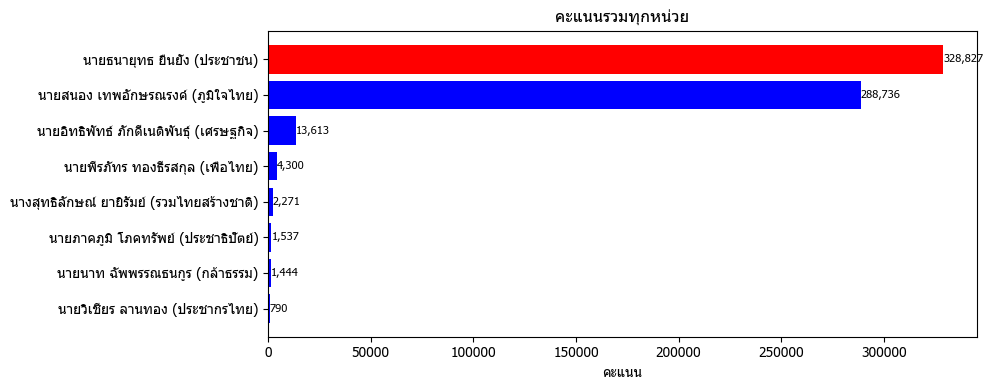

In [12]:
d1 = (district_scores.groupby(["ชื่อผู้สมัคร", "พรรค"], as_index=False)["คะแนน"]
        .sum().sort_values("คะแนน", ascending=False).reset_index(drop=True))
d1.index += 1
d1["% คะแนน"] = (d1["คะแนน"] / d1["คะแนน"].sum() * 100).round(2)

display(d1)

fig, ax = plt.subplots(figsize=(10, max(4, len(d1) * 0.5)))
colors = ["red" if i == 0 else "blue" for i in range(len(d1))]
ax.barh(d1["ชื่อผู้สมัคร"] + " (" + d1["พรรค"] + ")", d1["คะแนน"], color=colors)
ax.set_xlabel("คะแนน")
ax.set_title("คะแนนรวมทุกหน่วย")
ax.invert_yaxis()
for i, v in enumerate(d1["คะแนน"]):
    ax.text(v + 10, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### 2. จำนวนหน่วยที่ผู้สมัครแต่ละคนชนะ

,ชื่อผู้สมัคร,พรรค,หน่วยที่ชนะ
1,นายสนอง เทพอักษรณรงค์,ภูมิใจไทย,261
2,นายธนายุทธ ยืนยั่ง,ประชาชน,10
3,นายอิทธิพัทธ์ ภักดีเนติพันธุ์,เศรษฐกิจ,4
4,นางสุทธิลักษณ์ ยายิรัมย์,รวมไทยสร้างชาติ,2
5,นายภาคภูมิ โภคทรัพย์,ประชาธิปัตย์,1
6,นายพีรภัทร ทองธีรสกุล,เพื่อไทย,1


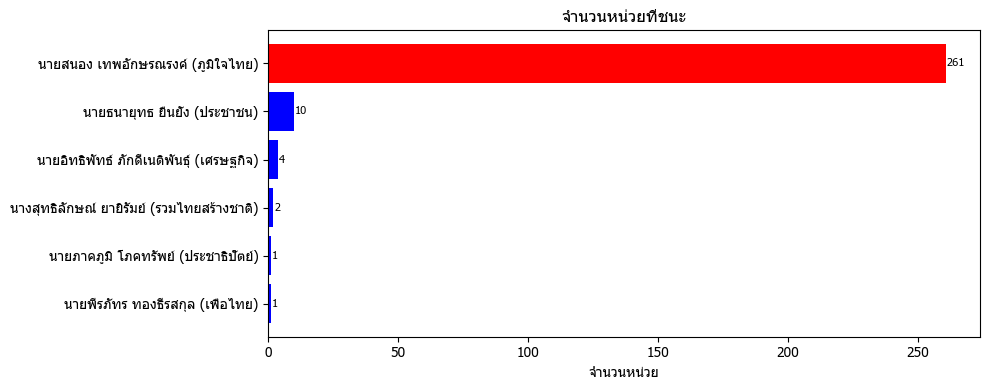

In [13]:
unit_winner = district_scores.loc[
    district_scores.groupby("unit_key")["คะแนน"].idxmax(), ["unit_key", "ชื่อผู้สมัคร", "พรรค"]
]
d2 = (unit_winner.groupby(["ชื่อผู้สมัคร", "พรรค"])
      .size().reset_index(name="หน่วยที่ชนะ")
      .sort_values("หน่วยที่ชนะ", ascending=False).reset_index(drop=True))
d2.index += 1

display(d2)

fig, ax = plt.subplots(figsize=(10, max(4, len(d2) * 0.5)))
colors = ["red" if i == 0 else "blue" for i in range(len(d2))]
ax.barh(d2["ชื่อผู้สมัคร"] + " (" + d2["พรรค"] + ")", d2["หน่วยที่ชนะ"], color=colors)
ax.set_xlabel("จำนวนหน่วย")
ax.set_title("จำนวนหน่วยที่ชนะ")
ax.invert_yaxis()
for i, v in enumerate(d2["หน่วยที่ชนะ"]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()

### 3. อัตราการมาใช้สิทธิเลือกตั้งสส.เขตรายตำบล

อัตราการมาใช้สิทธิเลือกตั้งเฉลี่ยทั้งหมด: 120.0%
อัตราการมาใช้สิทธิเลือกตั้งสูงสุด: 11598.9%
อัตราการมาใช้สิทธิเลือกตั้งต่ำสุด (หน่วย): 8.9%


C:\Users\USER\AppData\Local\Temp\ipykernel_14684\3972605222.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  district_summary.groupby("ตำบล").apply(lambda x: (


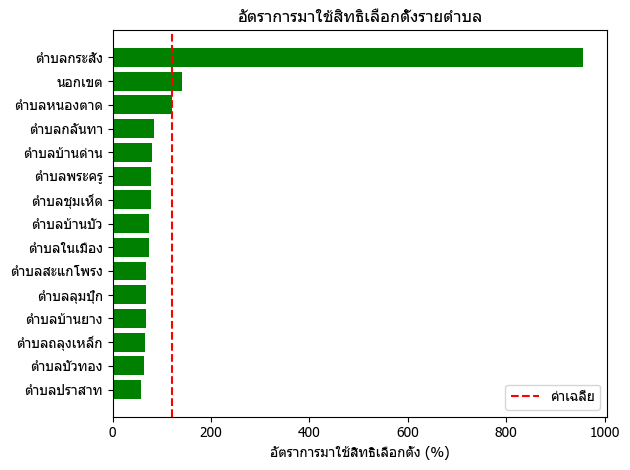

In [14]:
district_summary["อัตราการมาใช้สิทธิเลือกตั้ง"] = (
    (district_summary["บัตรดี"] + district_summary["บัตรเสีย"] + district_summary["ไม่เลือกผู้ใด"])
        / district_summary["จำนวนบัตรทั้งหมด"]
).replace([np.inf, -np.inf], np.nan)

turnout_by_tambon = (
    district_summary.groupby("ตำบล").apply(lambda x: (
        (x["บัตรดี"] + x["บัตรเสีย"] + x["ไม่เลือกผู้ใด"]).sum()
        / x["จำนวนบัตรทั้งหมด"].sum()
    ))
    .reset_index().rename(columns={0: "อัตราการมาใช้สิทธิเลือกตั้ง"}).sort_values("อัตราการมาใช้สิทธิเลือกตั้ง", ascending=False)
)

print(f"อัตราการมาใช้สิทธิเลือกตั้งเฉลี่ยทั้งหมด: {district_summary['อัตราการมาใช้สิทธิเลือกตั้ง'].mean():.1%}")
print(f"อัตราการมาใช้สิทธิเลือกตั้งสูงสุด: {district_summary['อัตราการมาใช้สิทธิเลือกตั้ง'].max():.1%}")
print(f"อัตราการมาใช้สิทธิเลือกตั้งต่ำสุด (หน่วย): {district_summary['อัตราการมาใช้สิทธิเลือกตั้ง'].min():.1%}")

fig, ax = plt.subplots()
ax.barh(turnout_by_tambon["ตำบล"], turnout_by_tambon["อัตราการมาใช้สิทธิเลือกตั้ง"] * 100, color="green")
ax.set_xlabel("อัตราการมาใช้สิทธิเลือกตั้ง (%)")
ax.set_title("อัตราการมาใช้สิทธิเลือกตั้งรายตำบล")
ax.axvline(district_summary["อัตราการมาใช้สิทธิเลือกตั้ง"].mean() * 100, color="red", linestyle="--", label="ค่าเฉลี่ย")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4. การกระจายคะแนนแต่ละพรรครายตำบล

พรรค,กล้าธรรม,ประชากรไทย,ประชาชน,ประชาธิปัตย์,ภูมิใจไทย,รวมไทยสร้างชาติ,เพื่อไทย,เศรษฐกิจ
ตำบล,,,,,,,,
ตำบลกระสัง,28.0,25.0,878.0,35.0,5159.0,466.0,251.0,11141.0
ตำบลกลันทา,18.0,15.0,440.0,21.0,2529.0,19.0,172.0,17.0
ตำบลชุมเห็ด,63.0,62.0,1974.0,192.0,7059.0,218.0,316.0,486.0
ตำบลถลุงเหล็ก,7.0,95.0,281.0,18.0,2202.0,14.0,106.0,17.0
ตำบลบัวทอง,17.0,23.0,312615.0,40.0,2290.0,20.0,132.0,148.0
ตำบลบ้านด่าน,65.0,21.0,1335.0,62.0,6062.0,87.0,519.0,58.0
ตำบลบ้านบัว,35.0,30.0,1904.0,142.0,11505.0,47.0,290.0,37.0
ตำบลบ้านยาง,33.0,44.0,1295.0,81.0,5097.0,49.0,263.0,58.0
ตำบลปราสาท,28.0,17.0,535.0,30.0,223916.0,33.0,239.0,24.0


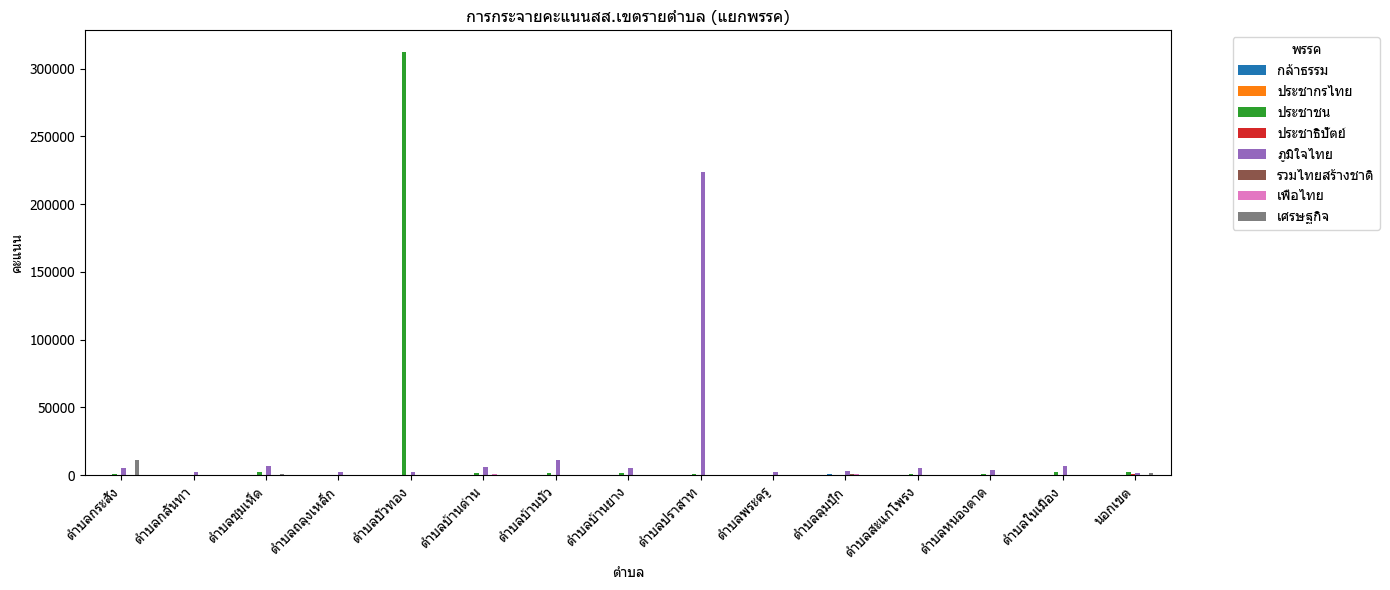

In [15]:
d4 = district_scores.groupby(["ตำบล", "พรรค"], as_index=False)["คะแนน"].sum()
d4_pivot = d4.pivot_table(index="ตำบล", columns="พรรค", values="คะแนน", fill_value=0)
d4_pivot.plot(kind="bar", figsize=(14, 6), title="การกระจายคะแนนสส.เขตรายตำบล (แยกพรรค)")

display(d4_pivot)

plt.ylabel("คะแนน")
plt.xlabel("ตำบล")
plt.xticks(rotation=45, ha="right")
plt.legend(title="พรรค", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

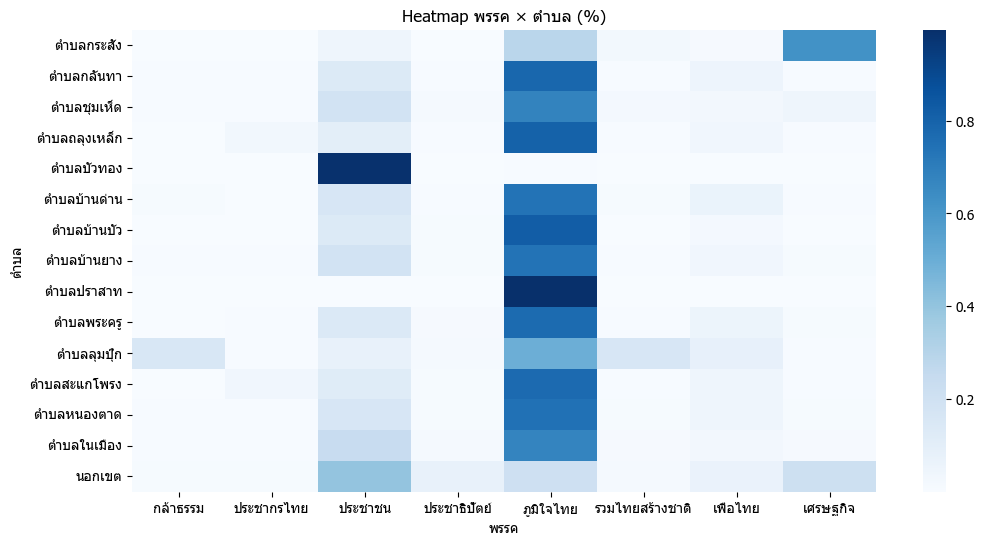

In [16]:
pivot_const = district_scores.pivot_table(index="ตำบล", columns="พรรค", values="คะแนน",
                                          aggfunc="sum", fill_value=0)

pivot_const_pct = pivot_const.div(pivot_const.sum(axis=1), axis=0)

top_const = pivot_const_pct.sum().index
pivot_const_pct = pivot_const_pct[top_const]

plt.figure(figsize=(12,6))
sns.heatmap(pivot_const_pct, cmap="Blues")
plt.title("Heatmap พรรค × ตำบล (%)")
plt.show()

### 5. บัตรเสียรายตำบล

In [17]:
tambon_bad = (district_summary.groupby(["ตำบล", "อำเภอ"])
              .agg({"บัตรเสีย": "sum", "จำนวนบัตรทั้งหมด": "sum"}).reset_index())

tambon_bad["bad_ballot_pct"] = (tambon_bad["บัตรเสีย"] / tambon_bad["จำนวนบัตรทั้งหมด"]).replace([np.inf, -np.inf], np.nan)

total_bad = tambon_bad["บัตรเสีย"].sum()
tambon_bad["bad_ballot_share"] = tambon_bad["บัตรเสีย"] / total_bad
tambon_bad = tambon_bad.sort_values("บัตรเสีย", ascending=False)
display(tambon_bad)

,ตำบล,อำเภอ,บัตรเสีย,จำนวนบัตรทั้งหมด,bad_ballot_pct,bad_ballot_share
0,ตำบลกระสัง,อำเภอเมืองบุรีรัมย์,5920,5990,0.988314,0.331356
14,นอกเขต,นอกเขต,2594,6101,0.425176,0.145192
2,ตำบลชุมเห็ด,อำเภอเมืองบุรีรัมย์,1384,15829,0.087434,0.077466
1,ตำบลกลันทา,อำเภอเมืองบุรีรัมย์,1272,5500,0.231273,0.071197
5,ตำบลบ้านด่าน,อำเภอบ้านด่าน,1205,9230,0.130553,0.067447
13,ตำบลในเมือง,อำเภอเมืองบุรีรัมย์,1003,16479,0.060865,0.056140
9,ตำบลพระครู,อำเภอเมืองบุรีรัมย์,943,5420,0.173985,0.052782
11,ตำบลสะแกโพรง,อำเภอเมืองบุรีรัมย์,786,10480,0.075000,0.043994
12,ตำบลหนองตาด,อำเภอเมืองบุรีรัมย์,682,9160,0.074454,0.038173
7,ตำบลบ้านยาง,อำเภอเมืองบุรีรัมย์,590,11160,0.052867,0.033024


### 6. พรรคที่ชนะในแต่ละตำบล

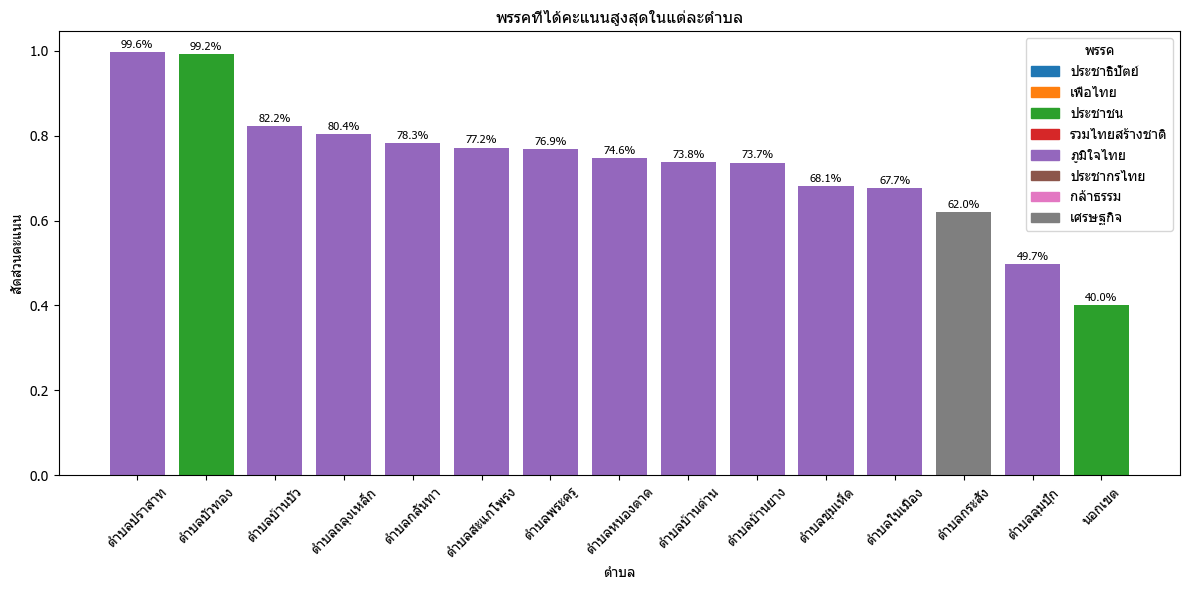

In [18]:
total_votes = district_scores.groupby('ตำบล')['คะแนน'].sum().reset_index(name='total_votes')
party_votes = district_scores.groupby(['ตำบล', 'พรรค'])['คะแนน'].sum().reset_index()

merged = party_votes.merge(total_votes, on='ตำบล')
merged['สัดส่วนคะแนน'] = merged['คะแนน'] / merged['total_votes']

top_party = merged.sort_values('สัดส่วนคะแนน', ascending=False).drop_duplicates('ตำบล')

party_colors = {p: c for p, c in zip(district_scores['พรรค'].unique(),plt.cm.tab10.colors)}

colors = top_party['พรรค'].map(party_colors)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_party)), top_party['สัดส่วนคะแนน'], color=colors)

for i, v in enumerate(top_party['สัดส่วนคะแนน']):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=8)

plt.xticks(range(len(top_party)), top_party['ตำบล'], rotation=45)
plt.title('พรรคที่ได้คะแนนสูงสุดในแต่ละตำบล')
plt.xlabel('ตำบล')
plt.ylabel('สัดส่วนคะแนน')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in party_colors.values()]
plt.legend(handles, party_colors.keys(), title='พรรค')

plt.tight_layout()
plt.show()

### 7. 5 หน่วยฐานเสียงแข็ง และ 5 หน่วยที่ต้องพัฒนาของแต่ละพรรค

0    0.247619
Name: margin_pct, dtype: float64
4    0.914634
3    0.934211
2    0.969466
1    0.998691
0    0.999625
Name: margin_pct, dtype: float64


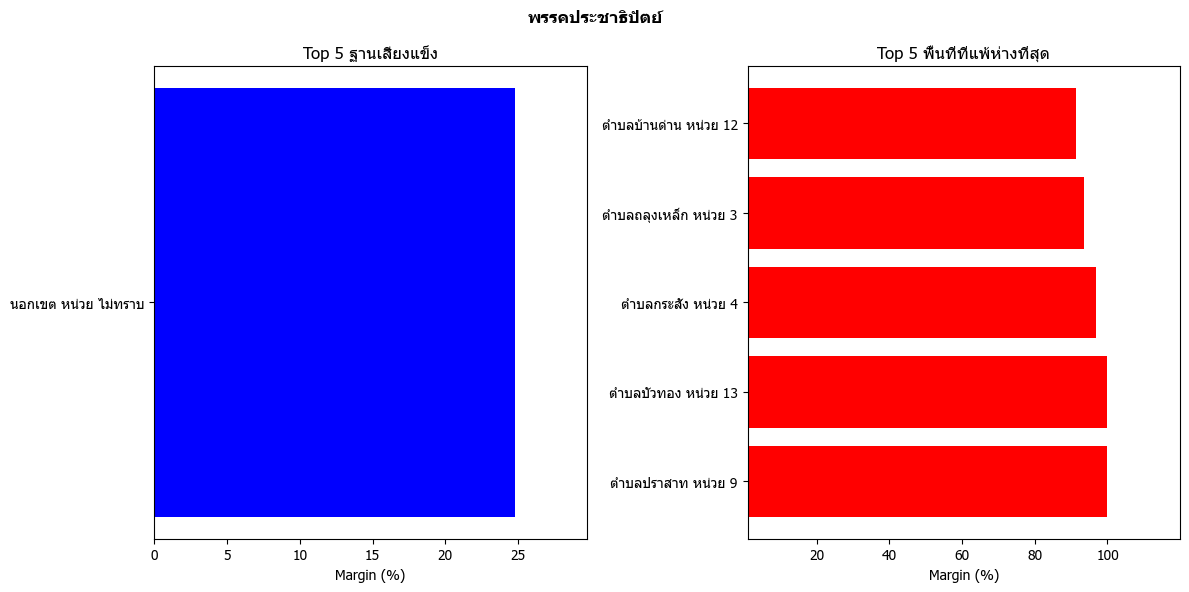

0    0.39501
Name: margin_pct, dtype: float64
4    0.914634
3    0.934211
2    0.969466
1    0.998691
0    0.999625
Name: margin_pct, dtype: float64


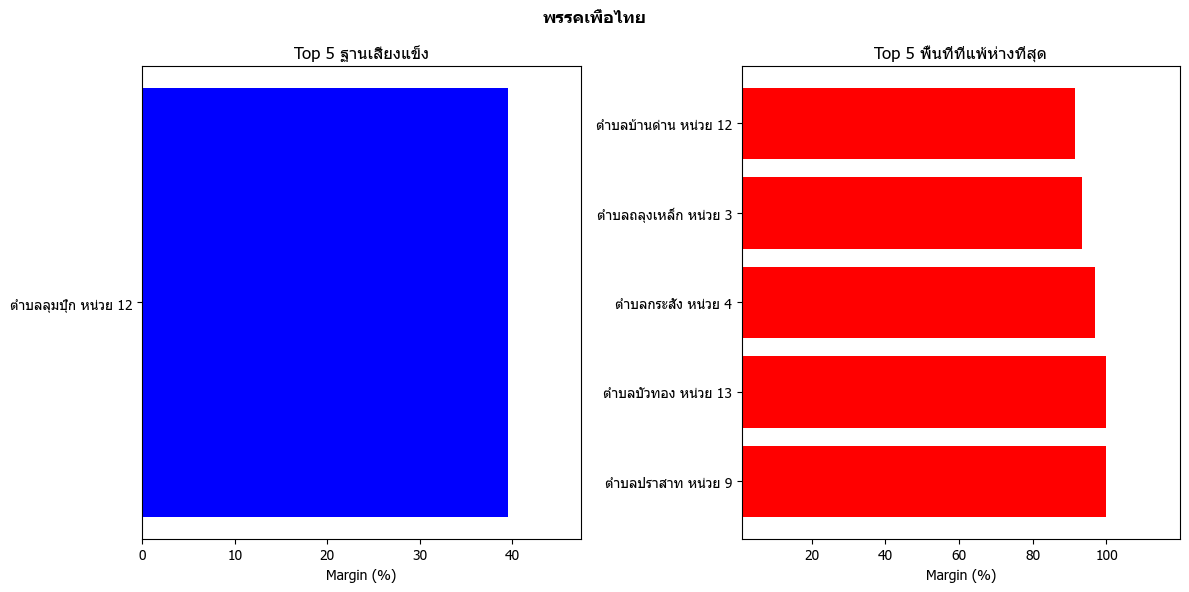

4    0.260664
3    0.277372
2    0.345146
1    0.508434
0    0.998691
Name: margin_pct, dtype: float64
4    0.909152
3    0.914634
2    0.934211
1    0.969466
0    0.999625
Name: margin_pct, dtype: float64


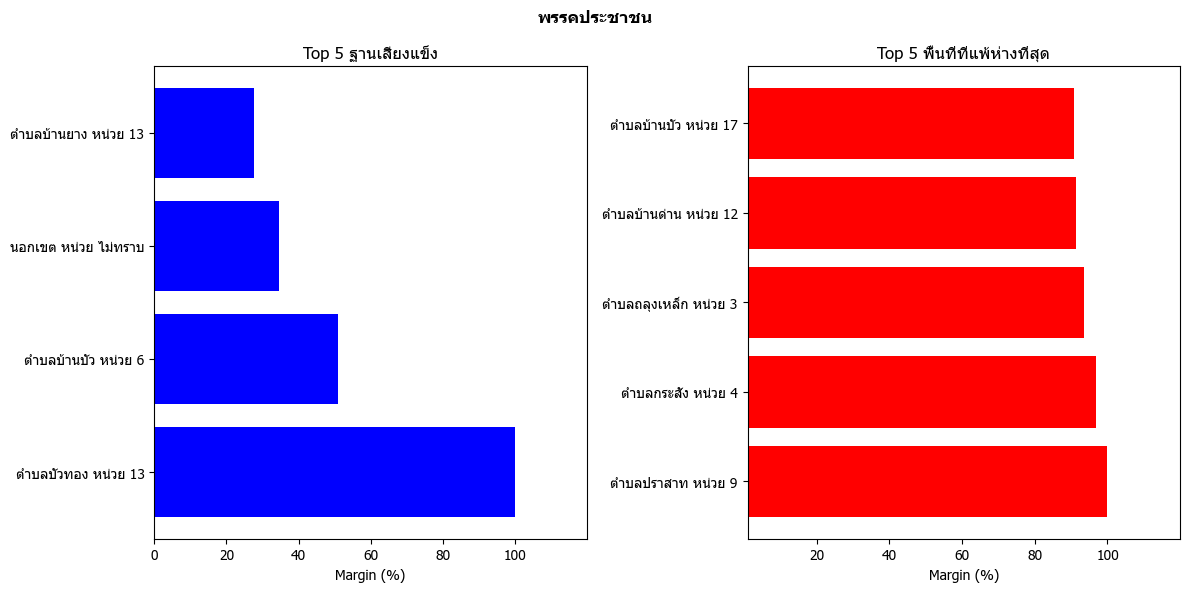

1    0.000000
0    0.029126
Name: margin_pct, dtype: float64
4    0.914634
3    0.934211
2    0.969466
1    0.998691
0    0.999625
Name: margin_pct, dtype: float64


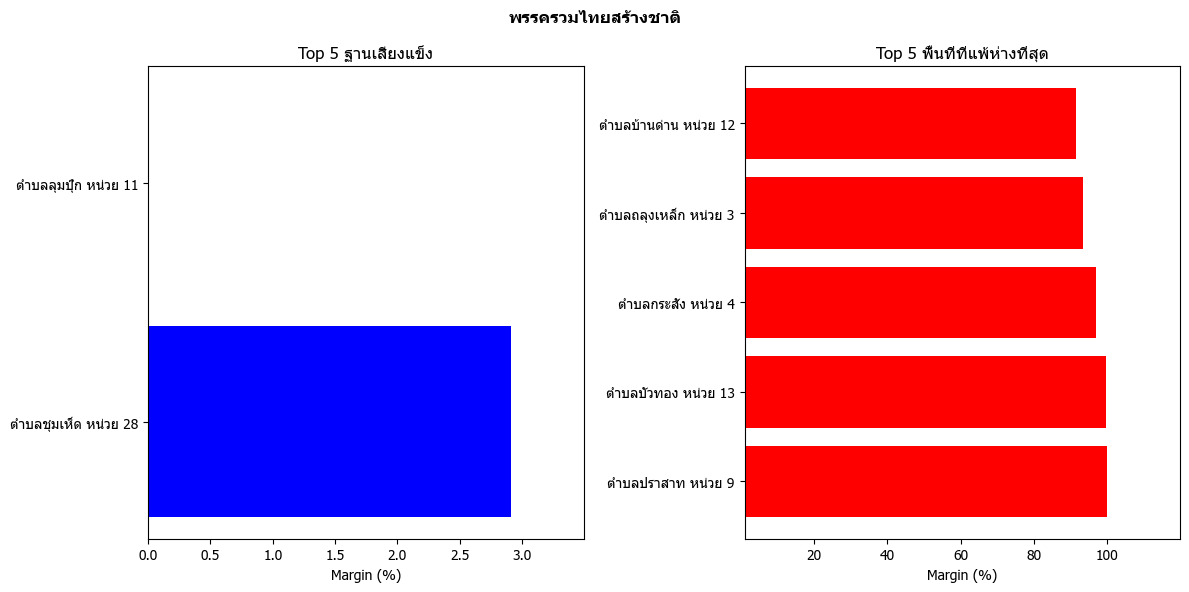

4    0.849462
3    0.909152
2    0.914634
1    0.934211
0    0.999625
Name: margin_pct, dtype: float64
4    0.395010
3    0.488666
2    0.508434
1    0.969466
0    0.998691
Name: margin_pct, dtype: float64


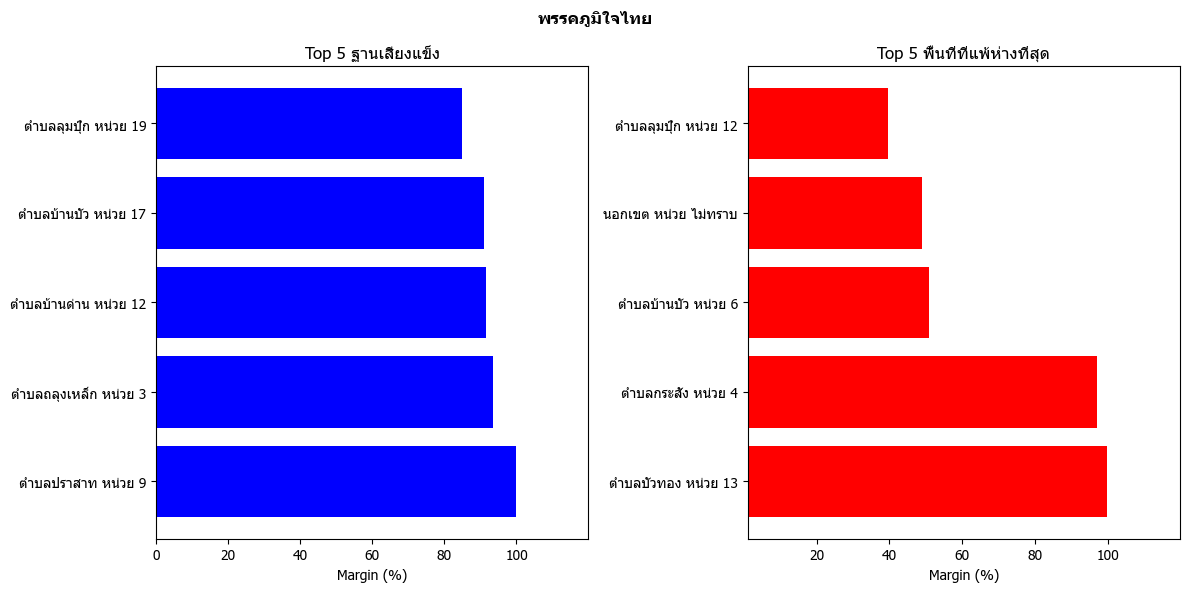

4    0.914634
3    0.934211
2    0.969466
1    0.998691
0    0.999625
Name: margin_pct, dtype: float64


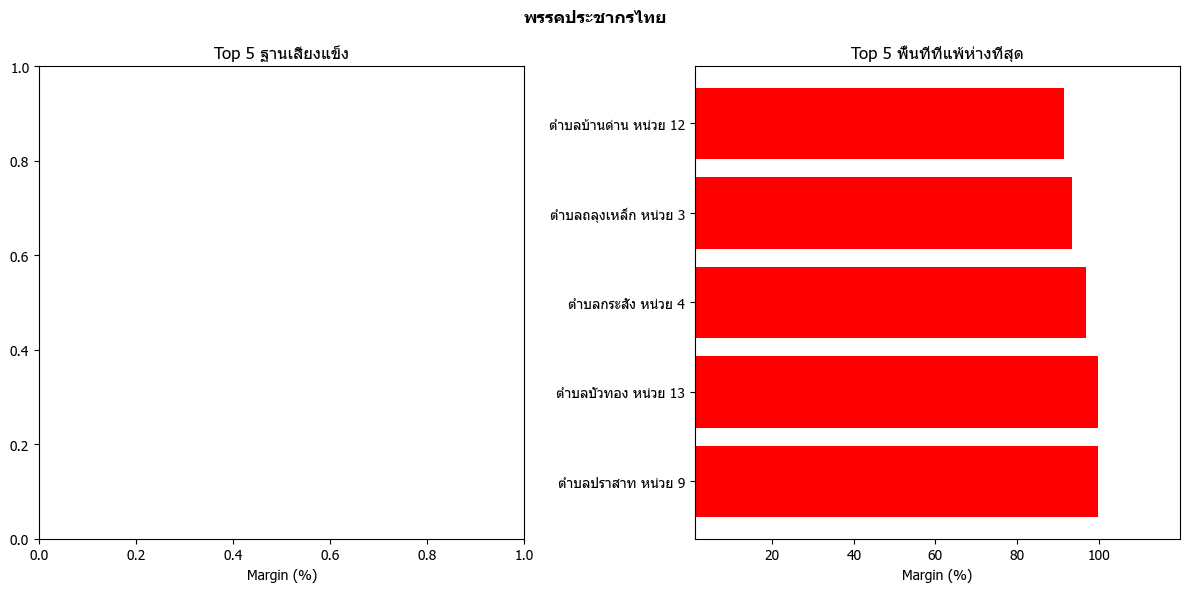

4    0.914634
3    0.934211
2    0.969466
1    0.998691
0    0.999625
Name: margin_pct, dtype: float64


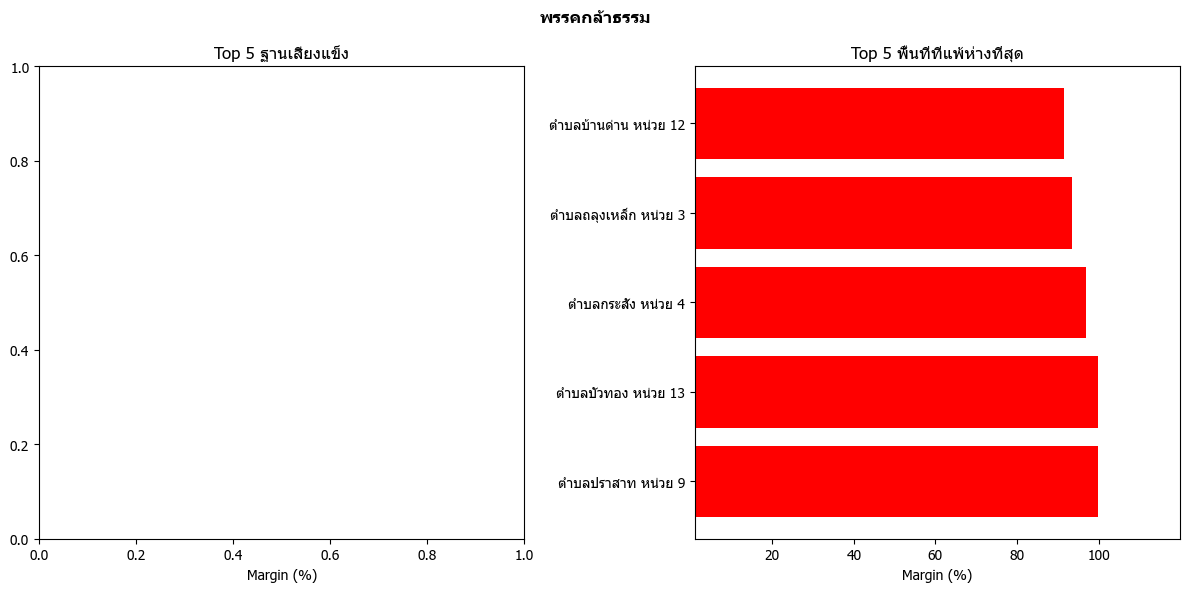

3    0.036254
2    0.077922
1    0.488666
0    0.969466
Name: margin_pct, dtype: float64
4    0.909152
3    0.914634
2    0.934211
1    0.998691
0    0.999625
Name: margin_pct, dtype: float64


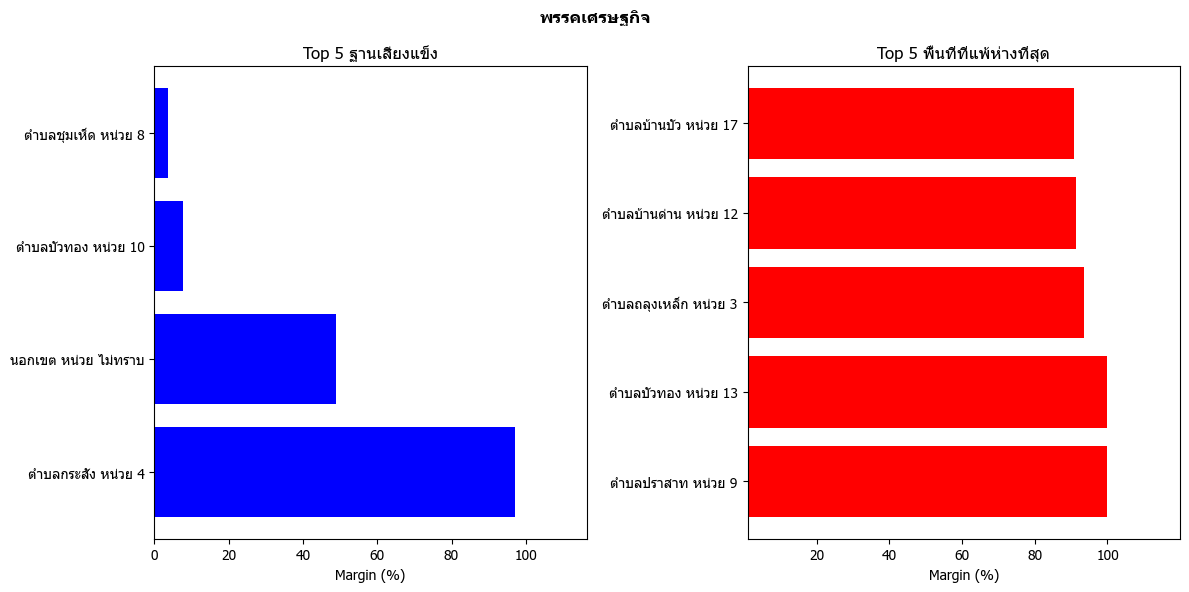

In [19]:
TOP_UNIT = 5

def calc_margin(group):
    group = group.sort_values("คะแนน", ascending=False).reset_index(drop=True)
    if len(group) < 2:
        return pd.Series({"winner": group.loc[0, "ชื่อผู้สมัคร"], "พรรค": group.loc[0, "พรรค"],
                          "winner_score": group.loc[0, "คะแนน"], "margin": group.loc[0, "คะแนน"], "margin_pct": 1.0})
    margin = group.loc[0, "คะแนน"] - group.loc[1, "คะแนน"]
    total = group["คะแนน"].sum()
    return pd.Series({"winner": group.loc[0, "ชื่อผู้สมัคร"], "พรรค": group.loc[0, "พรรค"],
                      "winner_score": group.loc[0, "คะแนน"], "margin": margin, "margin_pct": margin / total})

unit_margin = district_scores.groupby("unit_key").apply(calc_margin, include_groups=False).reset_index()
unit_margin = unit_margin.merge(district_scores[["unit_key", "หน่วย", "ตำบล", "อำเภอ"]].drop_duplicates(), on="unit_key")

parties = district_scores["พรรค"].unique()

for party in parties:
    own = unit_margin[unit_margin["พรรค"] == party].copy()
    lost = unit_margin[unit_margin["พรรค"] != party].copy()
    own_sorted = own.sort_values("margin_pct", ascending=False).head(TOP_UNIT).reset_index(drop=True)
    lost_sorted = lost.sort_values("margin_pct", ascending=False).head(TOP_UNIT).reset_index(drop=True)

    if own_sorted.empty and lost_sorted.empty:
        continue

    n_rows = max(len(own_sorted), len(lost_sorted), 1)
    fig_height = max(4, n_rows * 1.2)

    fig, axes = plt.subplots(1, 2, figsize=(12, fig_height))
    fig.suptitle(f"พรรค{party}", fontweight="bold")

    if not own_sorted.empty:
        own_sorted = own_sorted.dropna(subset=["ตำบล", "หน่วย"]).reset_index(drop=True)
        print(own_sorted["margin_pct"].sort_values())
        values = own_sorted["margin_pct"] * 100
        axes[0].barh(own_sorted["ตำบล"] + " หน่วย " + own_sorted["หน่วย"], values, color="blue")
        axes[0].set_xlim(0, values.max() * 1.2)

    axes[0].set_xlabel("Margin (%)")
    axes[0].set_title(f"Top {TOP_UNIT} ฐานเสียงแข็ง")

    if not lost_sorted.empty:
        lost_sorted = lost_sorted.dropna(subset=["ตำบล", "หน่วย"]).reset_index(drop=True)
        print(lost_sorted["margin_pct"].sort_values())
        values = lost_sorted["margin_pct"] * 100
        axes[1].barh(lost_sorted["ตำบล"] + " หน่วย " + lost_sorted["หน่วย"],values, color="red")
        axes[1].set_xlim(1, values.max() * 1.2)

    axes[1].set_xlabel("Margin (%)")
    axes[1].set_title(f"Top {TOP_UNIT} พื้นที่ที่แพ้ห่างที่สุด")

    plt.tight_layout()
    plt.show()

## บัญชีรายชื่อ

In [20]:
TOP = 10

### 1. คะแนนรวมแต่ละพรรค (10 อันดับแรก)

,คะแนน,% คะแนน
พรรค,,
เศรษฐกิจ,9115846,91.842827
ภูมิใจไทย,142071,1.431376
ประชาชน,108901,1.097186
สร้างอนาคตไทย,82074,0.826902
ประชาธิปัตย์,81943,0.825582
ไทยชนะ,81395,0.820061
ประชาชาติ,81381,0.819920
ประชากรไทย,81190,0.817995
แรงงานสร้างชาติ,75686,0.762542


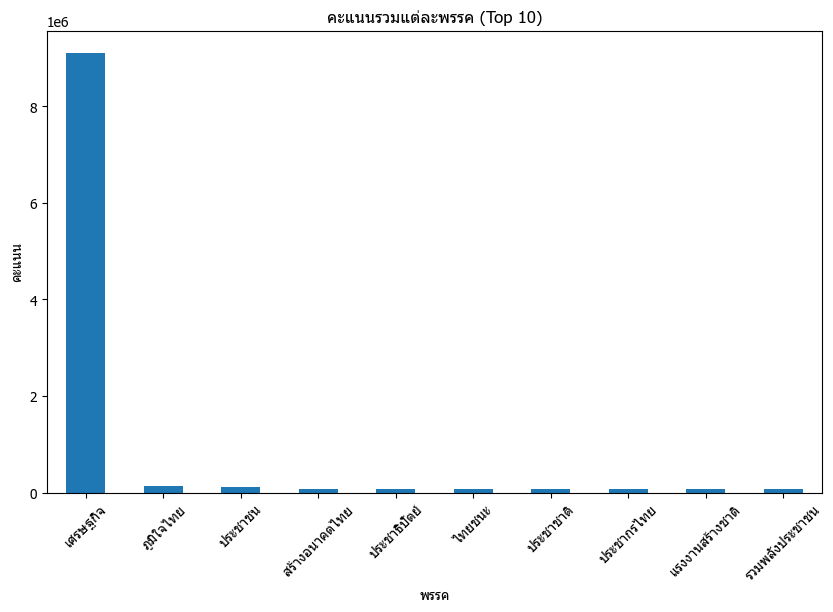

In [21]:
party_total_top = partylist_scores.groupby("พรรค")["คะแนน"].sum().sort_values(ascending=False).head(TOP)
party_total_top_df = pd.DataFrame(party_total_top, columns=["คะแนน"])
party_total_top_df["% คะแนน"] = party_total_top_df["คะแนน"] / party_total_top_df["คะแนน"].sum() * 100
display(party_total_top_df)

plt.figure(figsize=(10,6))
party_total_top.plot(kind="bar")
plt.title(f"คะแนนรวมแต่ละพรรค (Top {TOP})")
plt.ylabel("คะแนน")
plt.xticks(rotation=45)
plt.show()

### 2. พรรคที่ชนะในแต่ละตำบล

In [22]:
winner = partylist_scores.loc[partylist_scores.groupby("ตำบล")["คะแนน"].idxmax()][["ตำบล", "พรรค", "คะแนน"]]
display(winner.sort_values("ตำบล"))

,ตำบล,พรรค,คะแนน
3000,ตำบลกระสัง,ภูมิใจไทย,79633
3513,ตำบลกลันทา,ภูมิใจไทย,282
5540,ตำบลชุมเห็ด,เสรีรวมไทย,749
6622,ตำบลถลุงเหล็ก,เศรษฐกิจ,9034736
9131,ตำบลบัวทอง,เสรีรวมไทย,739
979,ตำบลบ้านด่าน,เศรษฐกิจ,6664
9897,ตำบลบ้านบัว,ภูมิใจไทย,934
10923,ตำบลบ้านยาง,ภูมิใจไทย,979
2145,ตำบลปราสาท,ภูมิใจไทย,263
11892,ตำบลพระครู,ภูมิใจไทย,282


### 3. จำนวนหน่วยที่แต่ละพรรคชนะ (Top 10)

,count
พรรค,
ภูมิใจไทย,20
เศรษฐกิจ,5
เสรีรวมไทย,3
รักชาติ,2
แรงงานสร้างชาติ,1
ไทยทรัพย์ทวี,1
รวมใจไทย,1


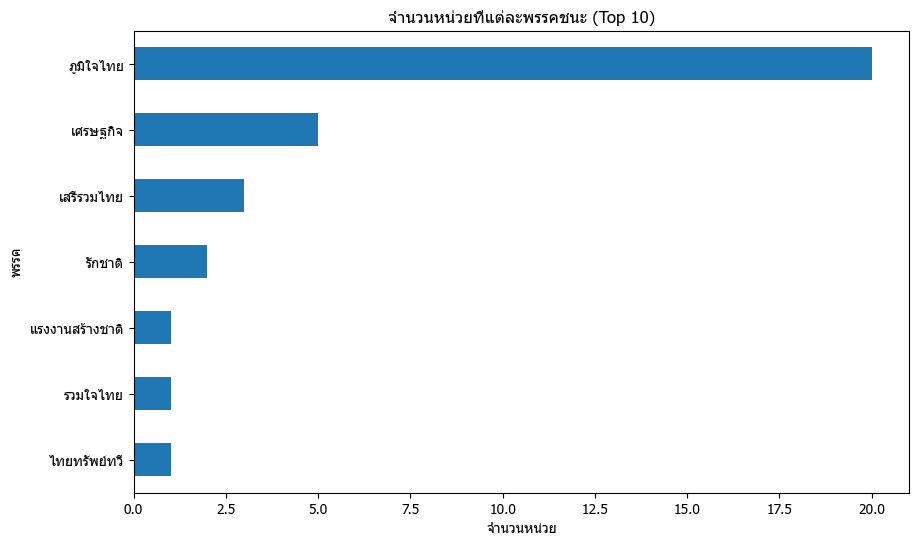

In [23]:
winner_unit = partylist_scores.loc[partylist_scores.groupby("หน่วย")["คะแนน"].idxmax()]
win_count = pd.DataFrame(winner_unit["พรรค"].value_counts().head(TOP))

display(win_count)

plt.figure(figsize=(10,6))
win_count["count"].sort_values().plot(kind="barh")
plt.title(f"จำนวนหน่วยที่แต่ละพรรคชนะ (Top {TOP})")
plt.xlabel("จำนวนหน่วย")
plt.show()

### 4. การกระจายคะแนนพรรคในแต่ละตำบล (Top 10 ของแต่ละตำบล)

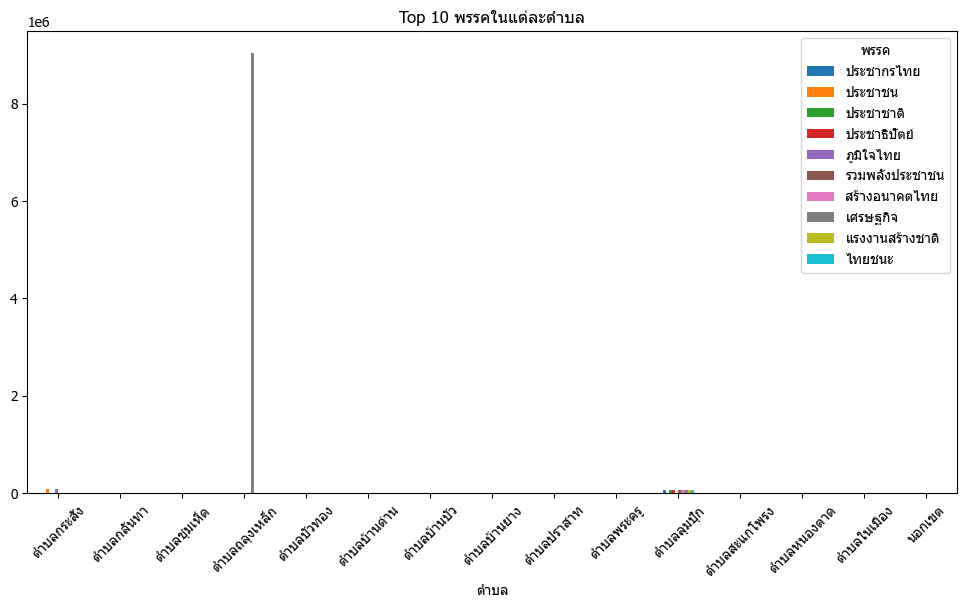

In [24]:
top = partylist_scores.groupby("พรรค")["คะแนน"].sum().nlargest(TOP).index
df_top = partylist_scores[partylist_scores["พรรค"].isin(top)]

pivot = df_top.pivot_table(index="ตำบล", columns="พรรค", values="คะแนน", aggfunc="sum",fill_value=0)

pivot.plot(kind="bar", figsize=(12,6))
plt.title(f"Top {TOP} พรรคในแต่ละตำบล")
plt.xticks(rotation=45)
plt.show()

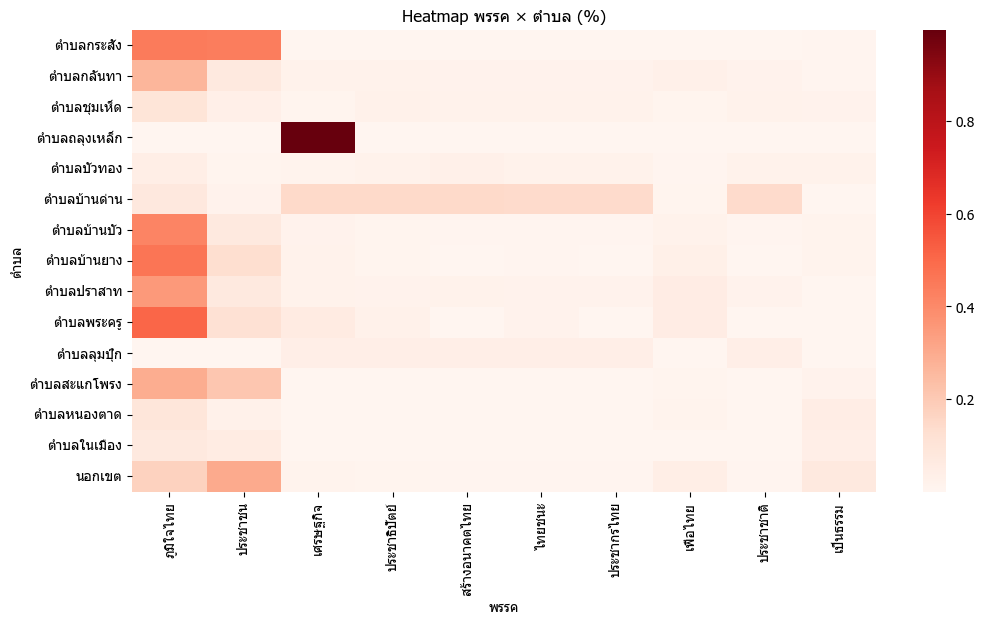

In [25]:
pivot = partylist_scores.pivot_table(index="ตำบล",columns="พรรค",values="คะแนน",aggfunc="sum",fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

top = pivot_pct.sum().nlargest(TOP).index
pivot_pct = pivot_pct[top]

plt.figure(figsize=(12,6))
sns.heatmap(pivot_pct, cmap="Reds")
plt.title("Heatmap พรรค × ตำบล (%)")
plt.show()

### 5. บัตรเสียรายตำบล

In [26]:
partylist_tambon = partylist_summary.groupby("ตำบล").agg({
        "บัตรเสีย": "sum",
        "จำนวนบัตรทั้งหมด": "sum"
    }).reset_index()

partylist_tambon["invalid_pct"] = (partylist_tambon["บัตรเสีย"] / partylist_tambon["จำนวนบัตรทั้งหมด"]
                                   ).replace([np.inf, -np.inf], np.nan)


total_bad = partylist_tambon["บัตรเสีย"].sum()
partylist_tambon["invalid_share"] = (partylist_tambon["บัตรเสีย"] / total_bad)

partylist_tambon = partylist_tambon.sort_values("บัตรเสีย", ascending=False)

display(partylist_tambon)

,ตำบล,บัตรเสีย,จำนวนบัตรทั้งหมด,invalid_pct,invalid_share
2,ตำบลชุมเห็ด,2378,15898,0.149579,0.224636
3,ตำบลถลุงเหล็ก,2062,4780,0.431381,0.194786
5,ตำบลบ้านด่าน,1051,9240,0.113745,0.099282
7,ตำบลบ้านยาง,961,11400,0.084298,0.090780
12,ตำบลหนองตาด,734,9160,0.080131,0.069337
13,ตำบลในเมือง,608,16297,0.037307,0.057434
6,ตำบลบ้านบัว,540,8241,0.065526,0.051011
0,ตำบลกระสัง,523,6140,0.085179,0.049405
9,ตำบลพระครู,504,5420,0.092989,0.047610
11,ตำบลสะแกโพรง,311,10640,0.029229,0.029378


### 6. พรรคที่ชนะในแต่ละตำบล

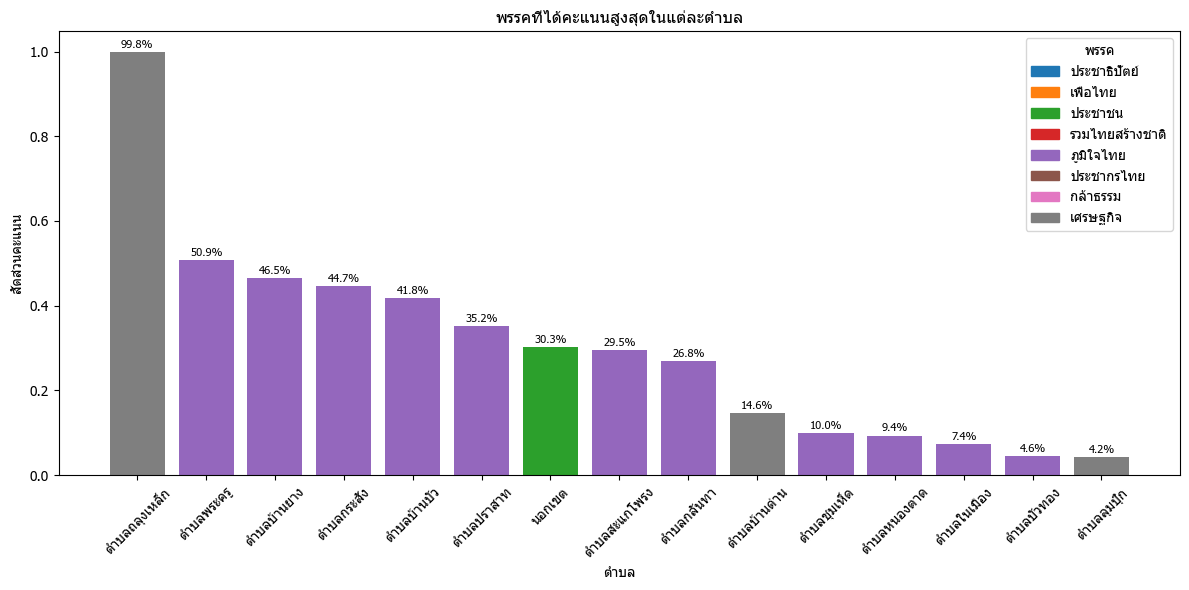

In [27]:
total_votes = partylist_scores.groupby('ตำบล')['คะแนน'].sum().reset_index(name='total_votes')
party_votes = partylist_scores.groupby(['ตำบล', 'พรรค'])['คะแนน'].sum().reset_index()

merged = party_votes.merge(total_votes, on='ตำบล')
merged['สัดส่วนคะแนน'] = merged['คะแนน'] / merged['total_votes']

top_party = merged.sort_values('สัดส่วนคะแนน', ascending=False).drop_duplicates('ตำบล')

party_colors = {p: c for p, c in zip(district_scores['พรรค'].unique(),plt.cm.tab10.colors)}

colors = top_party['พรรค'].map(party_colors)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_party)), top_party['สัดส่วนคะแนน'], color=colors)

for i, v in enumerate(top_party['สัดส่วนคะแนน']):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=8)

plt.xticks(range(len(top_party)), top_party['ตำบล'], rotation=45)
plt.title('พรรคที่ได้คะแนนสูงสุดในแต่ละตำบล')
plt.xlabel('ตำบล')
plt.ylabel('สัดส่วนคะแนน')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in party_colors.values()]
plt.legend(handles, party_colors.keys(), title='พรรค')

plt.tight_layout()
plt.show()

### 7. 5 หน่วยฐานเสียงแข็ง และ 5 หน่วยที่ต้องพัฒนาของแต่ละพรรค (พรรคที่ได้คะแนน Top 10)

3    0.000000
2    0.003077
1    0.433121
0    0.998062
Name: margin_pct, dtype: float64
4    0.789809
3    0.805009
2    0.870000
1    0.914216
0    0.928571
Name: margin_pct, dtype: float64


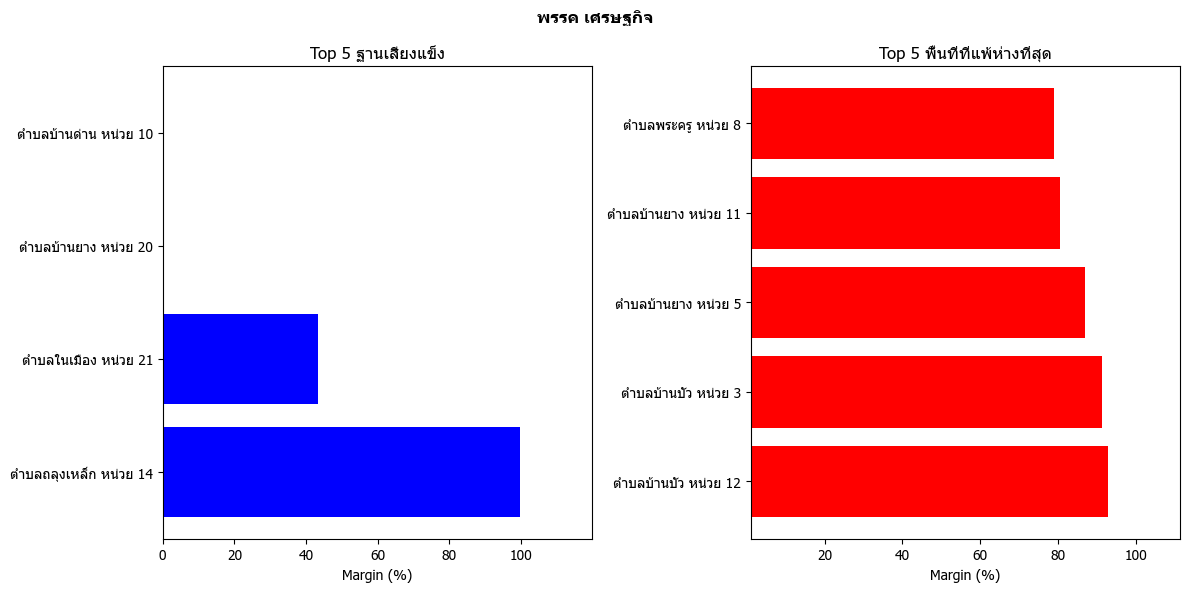

4    0.789809
3    0.805009
2    0.870000
1    0.914216
0    0.928571
Name: margin_pct, dtype: float64
4    0.583333
3    0.591818
2    0.626582
1    0.759808
0    0.998062
Name: margin_pct, dtype: float64


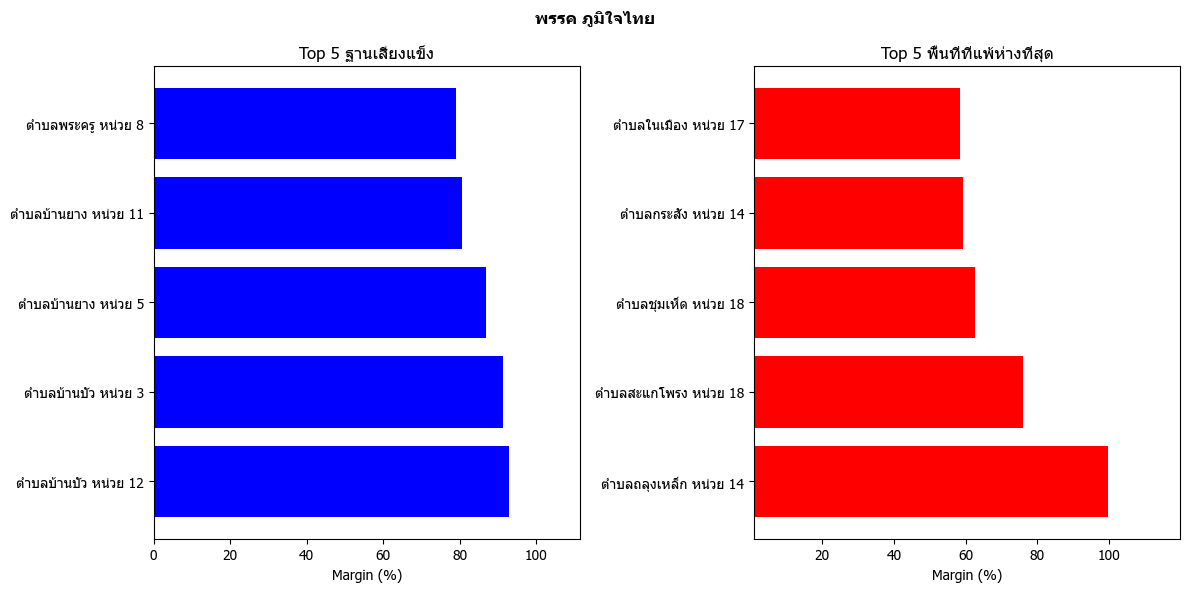

4    0.271942
3    0.307692
2    0.309593
1    0.522936
0    0.583333
Name: margin_pct, dtype: float64
4    0.805009
3    0.870000
2    0.914216
1    0.928571
0    0.998062
Name: margin_pct, dtype: float64


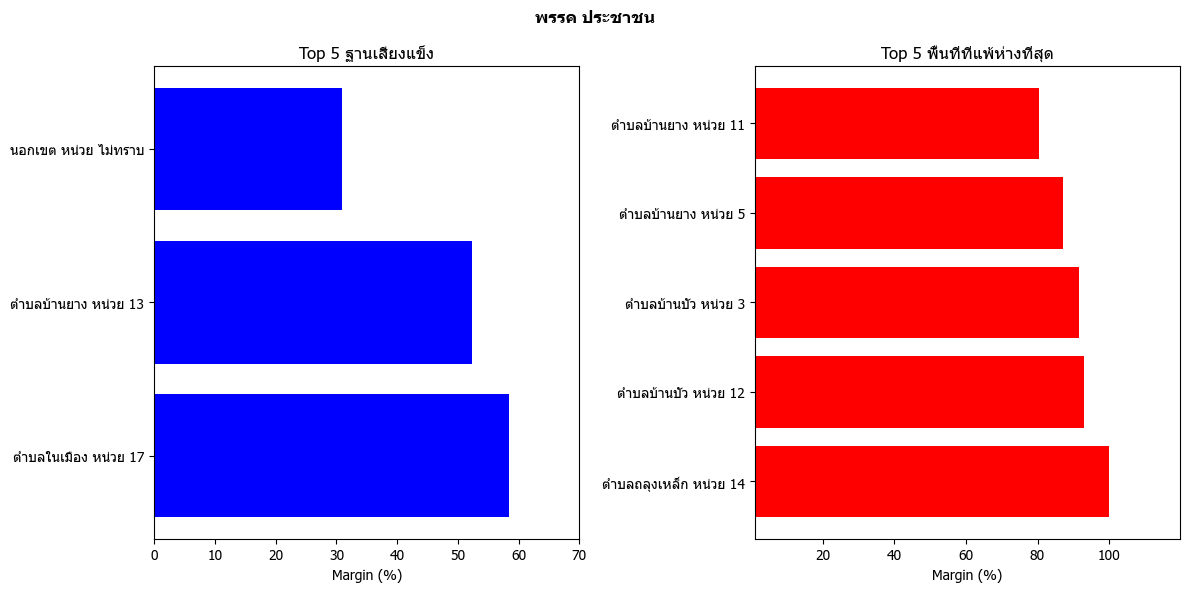

1    0.176339
0    0.189621
Name: margin_pct, dtype: float64
4    0.805009
3    0.870000
2    0.914216
1    0.928571
0    0.998062
Name: margin_pct, dtype: float64


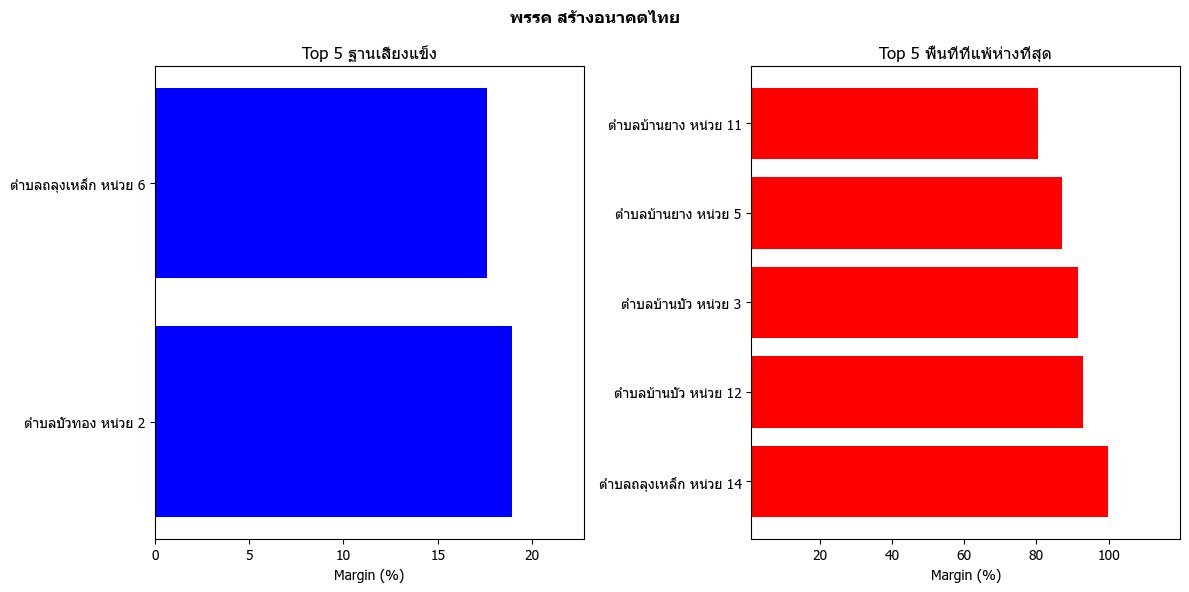

4    0.805009
3    0.870000
2    0.914216
1    0.928571
0    0.998062
Name: margin_pct, dtype: float64


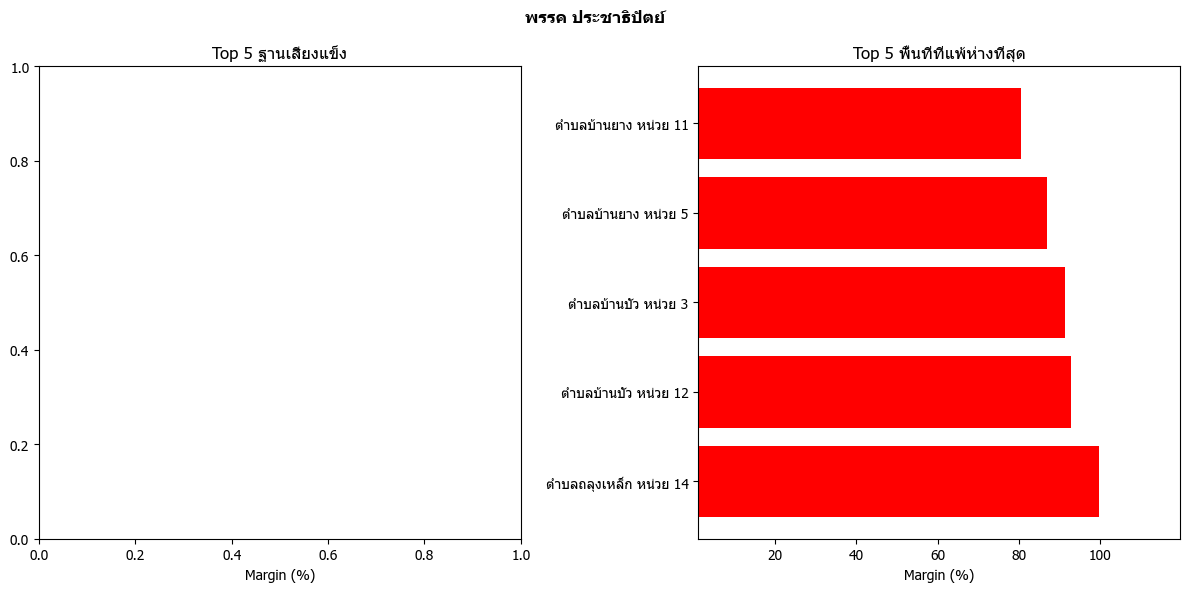

4    0.805009
3    0.870000
2    0.914216
1    0.928571
0    0.998062
Name: margin_pct, dtype: float64


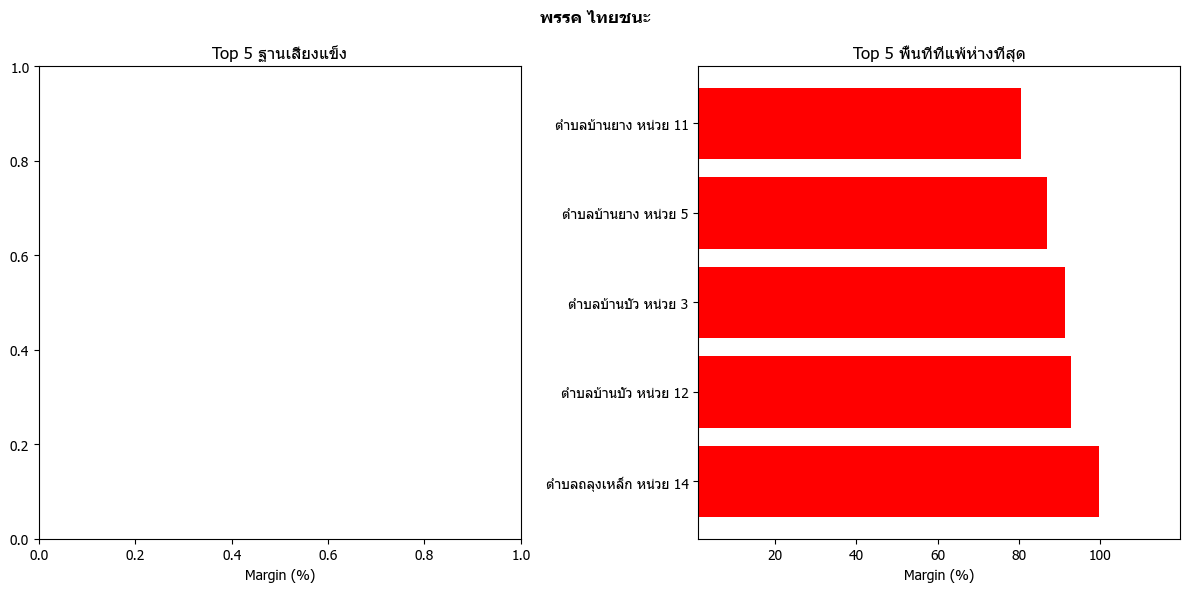

4    0.805009
3    0.870000
2    0.914216
1    0.928571
0    0.998062
Name: margin_pct, dtype: float64


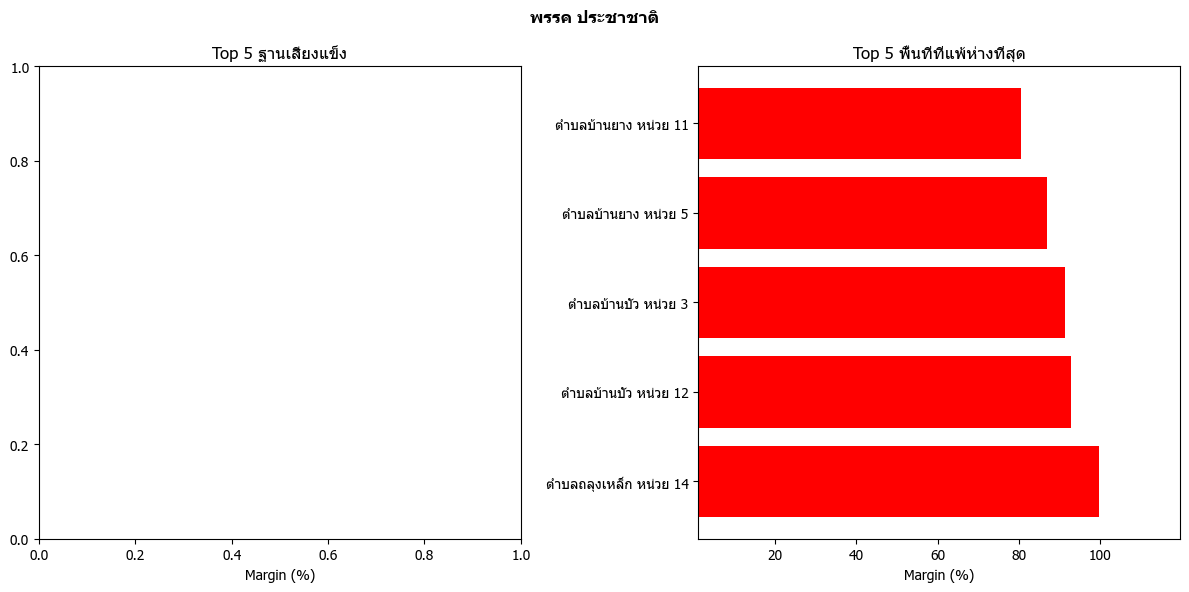

4    0.805009
3    0.870000
2    0.914216
1    0.928571
0    0.998062
Name: margin_pct, dtype: float64


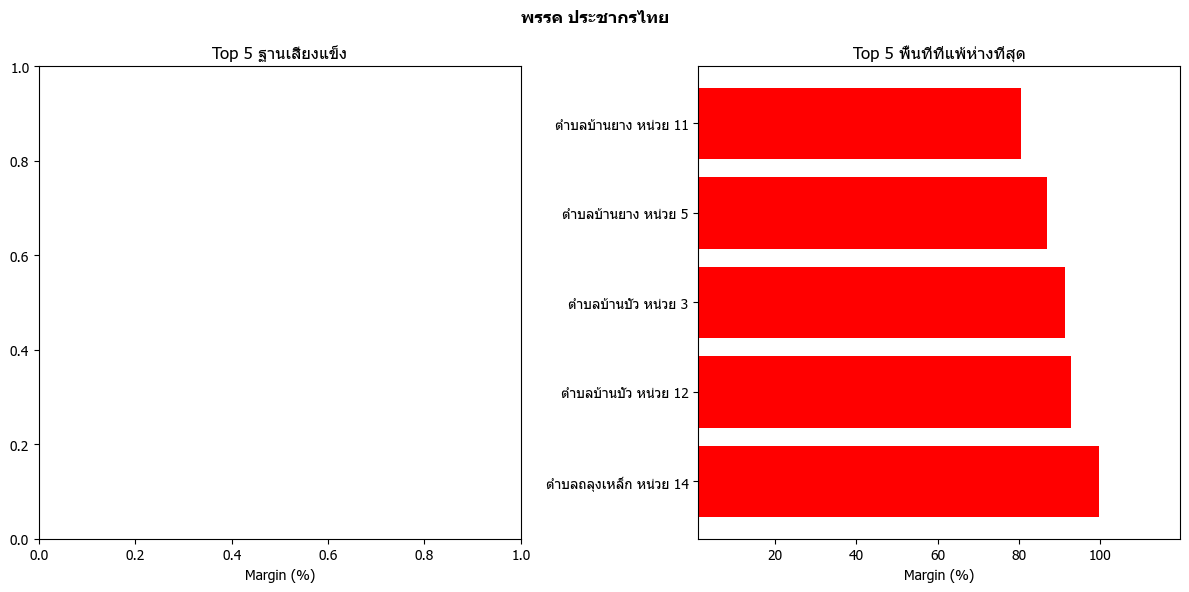

0    0.759808
Name: margin_pct, dtype: float64
4    0.805009
3    0.870000
2    0.914216
1    0.928571
0    0.998062
Name: margin_pct, dtype: float64


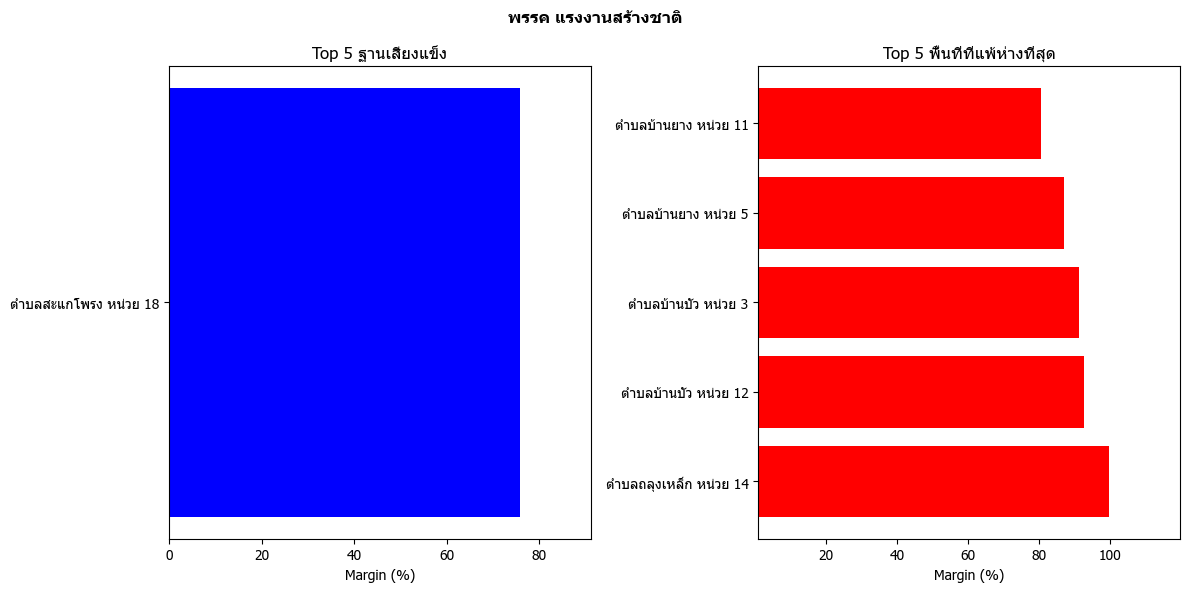

0    0.0
Name: margin_pct, dtype: float64
4    0.805009
3    0.870000
2    0.914216
1    0.928571
0    0.998062
Name: margin_pct, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_14684\2259024382.py:50: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axes[0].set_xlim(0, values.max() * 1.2)


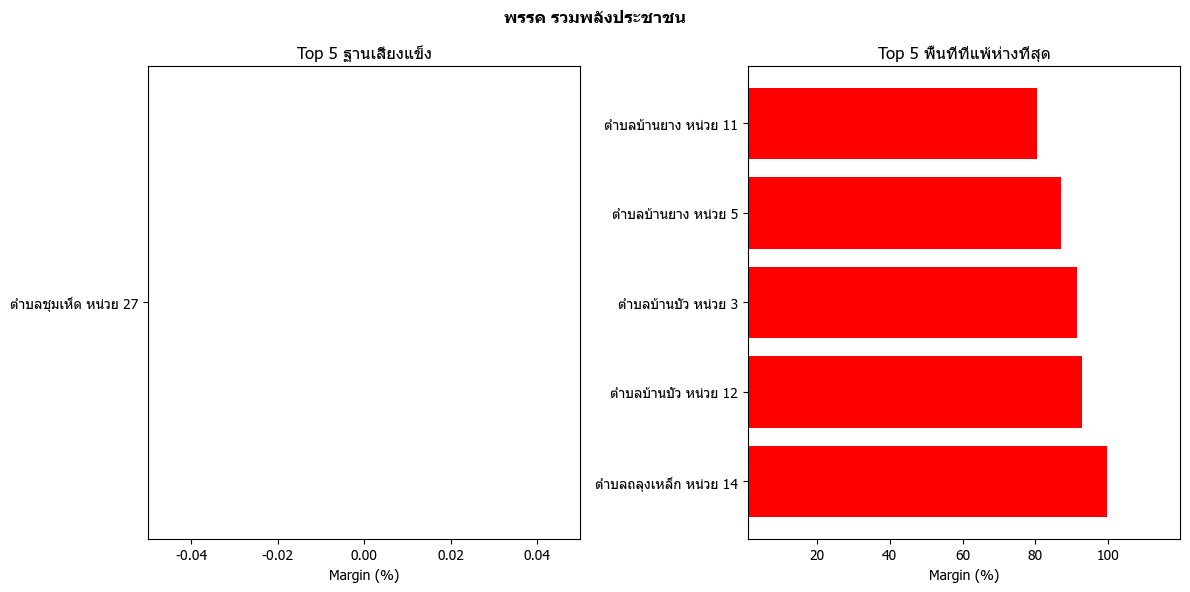

In [28]:
TOP_UNIT = 5

top_parties = partylist_scores.groupby("พรรค")["คะแนน"].sum().nlargest(TOP).index

def calc_margin_partylist(group):
    group = group.sort_values("คะแนน", ascending=False).reset_index(drop=True)
    
    if len(group) < 2:
        return pd.Series({
            "winner": group.loc[0, "พรรค"],
            "winner_score": group.loc[0, "คะแนน"],
            "margin": group.loc[0, "คะแนน"],
            "margin_pct": 1.0
        })
    
    margin = group.loc[0, "คะแนน"] - group.loc[1, "คะแนน"]
    total = group["คะแนน"].sum()
    
    return pd.Series({
        "winner": group.loc[0, "พรรค"],
        "winner_score": group.loc[0, "คะแนน"],
        "margin": margin,
        "margin_pct": margin / total
    })

unit_margin = partylist_scores.groupby("unit_key").apply(calc_margin_partylist, include_groups=False).reset_index()
unit_margin = unit_margin.merge(partylist_scores[["unit_key", "หน่วย", "ตำบล", "อำเภอ"]].drop_duplicates(), on="unit_key")

for party in top_parties:
    own = unit_margin[unit_margin["winner"] == party].copy()
    lost = unit_margin[unit_margin["winner"] != party].copy()

    own_sorted = own.sort_values("margin_pct", ascending=False).head(TOP_UNIT).reset_index(drop=True)
    lost_sorted = lost.sort_values("margin_pct", ascending=False).head(TOP_UNIT).reset_index(drop=True)

    if own_sorted.empty and lost_sorted.empty:
        continue

    n_rows = max(len(own_sorted), len(lost_sorted), 1)
    fig_height = max(4, n_rows * 1.2)

    fig, axes = plt.subplots(1, 2, figsize=(12, fig_height))
    fig.suptitle(f"พรรค {party}", fontweight="bold")

    if not own_sorted.empty:
        own_sorted = own_sorted.dropna(subset=["ตำบล", "หน่วย"]).reset_index(drop=True)
        print(own_sorted["margin_pct"].sort_values())
        values = own_sorted["margin_pct"] * 100
        axes[0].barh(own_sorted["ตำบล"] + " หน่วย " + own_sorted["หน่วย"], values, color="blue")
        axes[0].set_xlim(0, values.max() * 1.2)

    axes[0].set_xlabel("Margin (%)")
    axes[0].set_title(f"Top {TOP_UNIT} ฐานเสียงแข็ง")

    if not lost_sorted.empty:
        lost_sorted = lost_sorted.dropna(subset=["ตำบล", "หน่วย"]).reset_index(drop=True)
        print(lost_sorted["margin_pct"].sort_values())
        values = lost_sorted["margin_pct"] * 100
        axes[1].barh(lost_sorted["ตำบล"] + " หน่วย " + lost_sorted["หน่วย"],values, color="red")
        axes[1].set_xlim(1, values.max() * 1.2)

    axes[1].set_xlabel("Margin (%)")
    axes[1].set_title(f"Top {TOP_UNIT} พื้นที่ที่แพ้ห่างที่สุด")

    plt.tight_layout()
    plt.show()